# Introduction

## The skyrmion

In [169]:
import numpy as np
import matplotlib.pyplot as plt

def skyrmion_ansatz(b, nx, ny):
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> S^2;
    b is the size of the 'skyrmion'
    """
    X, Y = np.zeros((nx,ny)), np.zeros((nx,ny))
    for i in range(nx):
        for j in range(ny):
            X[i,j] = i
            Y[i,j] = j
        #end
    #end

    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    #rescale
    X *= 1/b; Y *= 1/b
    #compute the projection
    n = np.zeros((3, nx, ny))
    n[0,:,:] = 2*X/(1+X**2+Y**2)
    n[1,:,:] = 2*Y/(1+X**2+Y**2)
    n[2,:,:] = (X**2+Y**2-1)/(X**2+Y**2+1)
    return n
#end
    

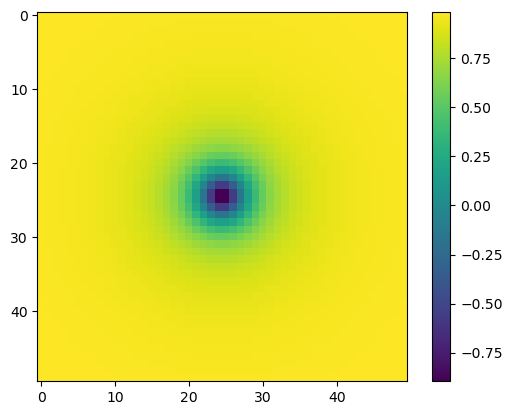

In [219]:
n = skyrmion_ansatz(3.0, 50,50)
plt.imshow(n[2,:,:])
plt.colorbar()

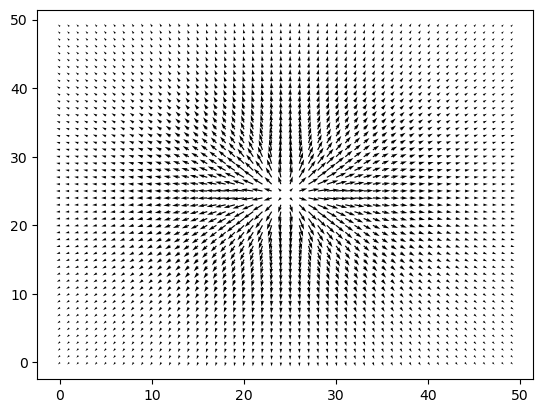

In [171]:
plt.quiver(n[1,:,:], n[0,:,:])

In [202]:
def H_vect(n,J1,J2,J3,B):
    E = 0
    nx = n.shape[1]; ny = n.shape[2]
    for i in range(nx):
        for j in range(ny):
            n_a = n[:,i,j]
            E -= B*n_a[2]
            for (k,l) in [(i+1,j),(i,j+1)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J1*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J2*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+2,j),(i,j+2)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J3*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )

    return E
#end
H_vect(n,1.0, -0.2, 0.0, 0.0)

-3977.1458787402516

Text(0, 0.5, 'energy (a.u.)')

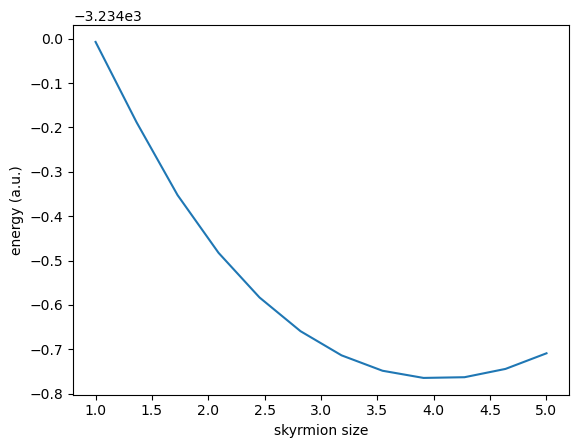

In [317]:
J1 = 1.0; J2 = -0.25; J3 = -0.10; B = -0.006
nx = 50; ny =50

b_vals = np.linspace(1.0,5,12)
H_vals = []
for b in b_vals:
    n = skyrmion_ansatz(b, nx, ny)
    E = H_vect(n,J1,J2,J3,B)
    H_vals.append(E)
#end

plt.plot(b_vals,H_vals)
plt.xlabel("skyrmion size"); plt.ylabel("energy (a.u.)")

## Relaxation dynamics

To minimize the energy, we would like to perform gradient descent on $n$ :
$$
\dot{n} = - \nabla_n H
$$
But this would be unphysical as we need to ensure $|n|=1$. To fix the issue, we simply subtract from the RHS the part proportional to $n$, obtaining
$$
\dot{n} = -\nabla_n H + (n \cdot \nabla_n H) \; n
$$
so that $n \dot{n} = 0$.


In [318]:
def relax(n_init, nx, ny, J1, J2, J3, B):
    """
    RK4 for dn/dt = F(n)
    """
    def F(n,nx,ny,J1,J2,J3,B):
        g = np.zeros_like(n) # MINUS the gradient of H
        for i in range(nx):
            for j in range(ny):
                #external field
                g[2,i,j] += B
                for (k,l) in [(i+1,j),(i,j+1)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J1* n[:,k,l]
                    g[:,k,l] += J1* n[:,i,j]

                for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J2* n[:,k,l]
                    g[:,k,l] += J2* n[:,i,j]

                for (k,l) in [(i+2,j),(i,j+2)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J3* n[:,k,l]
                    g[:,k,l] += J3* n[:,i,j]
            #end
        #end
        for i in range(nx):
            for j in range(ny):
                gn = n[0,i,j]*g[0,i,j] + n[1,i,j]*g[1,i,j] + n[2,i,j]*g[2,i,j]
                g[:,i,j] = g[:,i,j] - gn*n[:,i,j]
        return g
    #endfunction

    dt = 0.05
    F(n_init, nx,ny,J1, J2,J3,B)

    n_arr = np.zeros((30, 3, nx, ny))
    n = np.zeros_like(n_init)
    n = n_init
    for i in range(30):
        n_arr[i,:,:,:] = n
        k1 = F(n, nx, ny, J1, J2, J3, B)
        maxf = np.max(np.abs(k1))
        #adaptive time step
        #dt = 1E-2 / maxf
        #print("dt = ", dt)
        n += k1*dt
    return n_arr
        
    
#end
n_init = skyrmion_ansatz(4.0,nx,ny)
n_arr = relax(n_init, nx, ny, J1, J2, J3, B)

Text(0, 0.5, 'energy')

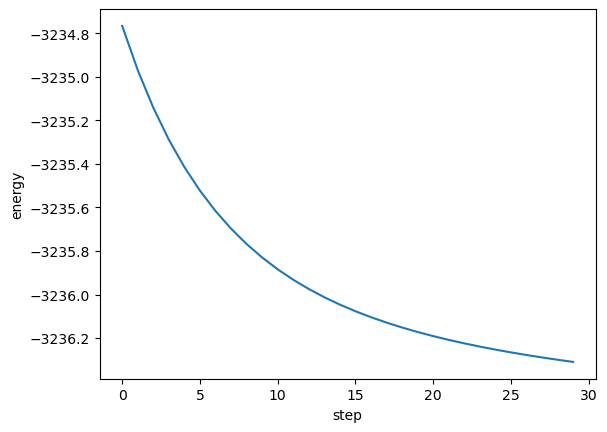

In [319]:
H_vals = [H_vect(n_arr[i,:,:,:],J1,J2,J3,B) for i in range(30)]
plt.plot(H_vals)
plt.xlabel("step"); plt.ylabel("energy")

In [320]:
H_vals[-1]

-3236.3095665390415

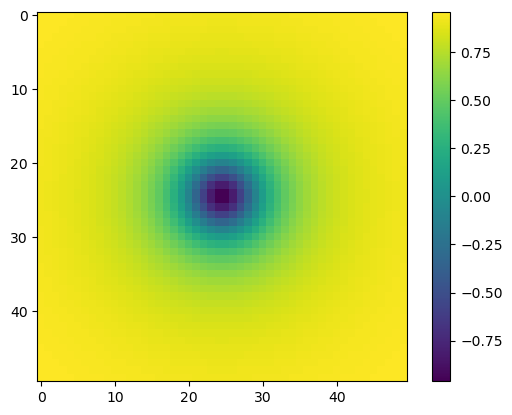

In [321]:
plt.imshow(n[2,:,:])
plt.colorbar()

## Sterographic projection and the Hamiltonian

$$
n_x = \frac{w + \bar{w}}{1+\bar{w}w} \qquad n_y = -i \frac{w - \bar{w}}{1+\bar{w}w} \qquad n_z = \frac{1-\bar{w}w}{1+\bar{w}w} 
$$

The inverse mapping is

$$
|w|^2 = \frac{1-n_z}{1+n_z} \qquad w = \frac{n_x + i n_y}{1+n_z}
$$

In [322]:
import numpy as np

def w_project(n):
    w = np.zeros((n.shape[1], n.shape[2]),dtype=complex)
    w = (n[0,:,:]+ 1j*n[1,:,:]) / (1+n[2,:,:])
    return w
#end

def n_vector(w):
    n = np.zeros((3, w.shape[0], w.shape[1]))
    n[0,:,:] = np.real( (w + np.conj(w)) / (1 + np.conj(w)*w) )
    n[1,:,:] = np.real(-1j * (w - np.conj(w)) / (1 + np.conj(w)*w))
    n[2,:,:] = np.real((1-w*np.conj(w)) / (1 + np.conj(w)*w))
    return n
#end

In [323]:
w0 = w_project(n)

In [324]:
def w(w0, lbd):
    return np.real(w0) + 1j*lbd*np.imag(w0)



In [329]:
def check_norm(n):
    norm = n[0,:,:]**2 + n[1,:,:]**2 + n[2,:,:]**2
    print("norm varies from", np.min(norm), "to", np.max(norm))

norm varies from 0.9999999999999996 to 1.0000000000000004


norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999994 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies from 0.9999999999999996 to 1.0000000000000004
norm varies fr

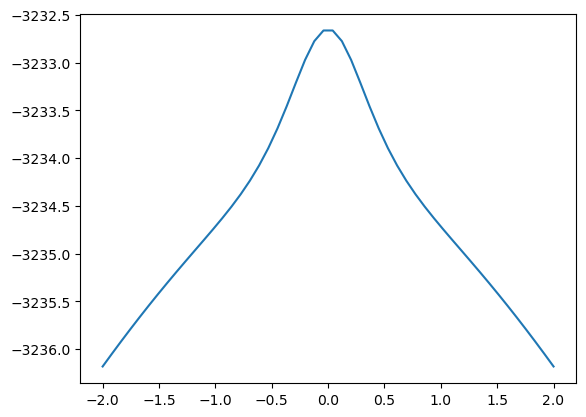

In [330]:
w0 = w_project(skyrmion_ansatz(3.2, nx,ny))
lbd_vals = np.linspace(-2, 2, 50)
H_vals = []
for lbd in lbd_vals:
    n = n_vector(w(w0,lbd))
    check_norm(n)
    H_vals.append(H_vect(n,J1,J2,J3,B))
plt.plot(lbd_vals,H_vals)


For my choice of parameters, skyrmions seem unstable...